<a href="https://www.kaggle.com/code/omborse771924/online-food-ordering-dataset-eda?scriptVersionId=346593661" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/online-food-ordering-dataset/online food delivery dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/online-food-ordering-dataset/online food delivery dataset.csv')

In [3]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
df.tail()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
387,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes


## Loading Dataset

In [5]:
df.describe

<bound method NDFrame.describe of      Age  Gender Marital Status Occupation  Monthly Income  \
0     20  Female         Single    Student       No Income   
1     24  Female         Single    Student  Below Rs.10000   
2     22    Male         Single    Student  Below Rs.10000   
3     22  Female         Single    Student       No Income   
4     22    Male         Single    Student  Below Rs.10000   
..   ...     ...            ...        ...             ...   
383   23  Female         Single    Student       No Income   
384   23  Female         Single    Student       No Income   
385   22  Female         Single    Student       No Income   
386   23    Male         Single    Student  Below Rs.10000   
387   23    Male         Single    Student       No Income   

    Educational Qualifications  Family size Customer Type  latitude  \
0                Post Graduate            4      Frequent   12.9766   
1                     Graduate            3       Regular   12.9770   
2       

In [6]:
df.info


<bound method DataFrame.info of      Age  Gender Marital Status Occupation  Monthly Income  \
0     20  Female         Single    Student       No Income   
1     24  Female         Single    Student  Below Rs.10000   
2     22    Male         Single    Student  Below Rs.10000   
3     22  Female         Single    Student       No Income   
4     22    Male         Single    Student  Below Rs.10000   
..   ...     ...            ...        ...             ...   
383   23  Female         Single    Student       No Income   
384   23  Female         Single    Student       No Income   
385   22  Female         Single    Student       No Income   
386   23    Male         Single    Student  Below Rs.10000   
387   23    Male         Single    Student       No Income   

    Educational Qualifications  Family size Customer Type  latitude  \
0                Post Graduate            4      Frequent   12.9766   
1                     Graduate            3       Regular   12.9770   
2         

In [7]:
df.isnull()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,False,False,False,False,False,False,False,False,False,False,False,False,False,False
384,False,False,False,False,False,False,False,False,False,False,False,False,False,False
385,False,False,False,False,False,False,False,False,False,False,False,False,False,False
386,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
383     True
384     True
385     True
386    False
387     True
Length: 388, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(103)

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 103


In [12]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

     Age  Gender Marital Status Occupation   Monthly Income  \
2     22    Male         Single    Student   Below Rs.10000   
3     22  Female         Single    Student        No Income   
4     22    Male         Single    Student   Below Rs.10000   
5     27  Female        Married   Employee  More than 50000   
6     22    Male         Single    Student        No Income   
..   ...     ...            ...        ...              ...   
382   24  Female         Single    Student        No Income   
383   23  Female         Single    Student        No Income   
384   23  Female         Single    Student        No Income   
385   22  Female         Single    Student        No Income   
387   23    Male         Single    Student        No Income   

    Educational Qualifications  Family size Customer Type  latitude  \
2                Post Graduate            3       Regular   12.9551   
3                     Graduate            6      Frequent   12.9473   
4                Post Graduate

In [13]:
df = df.drop_duplicates()

In [14]:
df = df.drop_duplicates(keep='last')

In [15]:
df = df[~df.duplicated(keep=False)]

In [16]:
df.duplicated().sum(
    
)

np.int64(0)

In [17]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback',
       'Unnamed: 13'],
      dtype='object')

## EDA

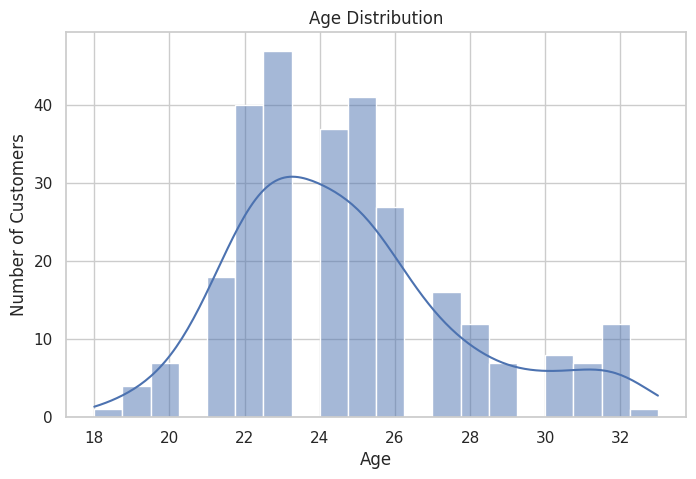

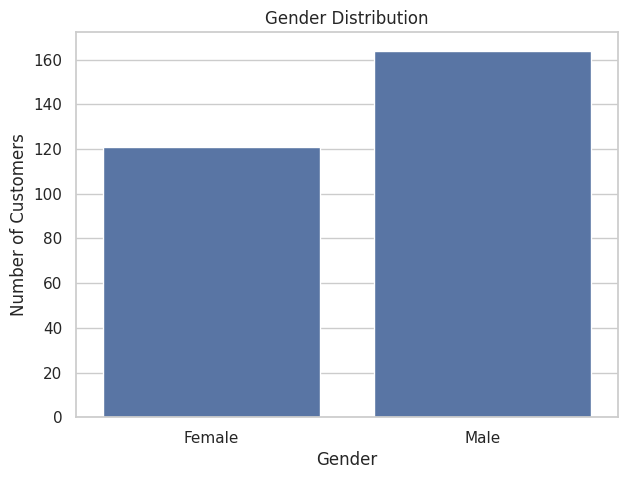

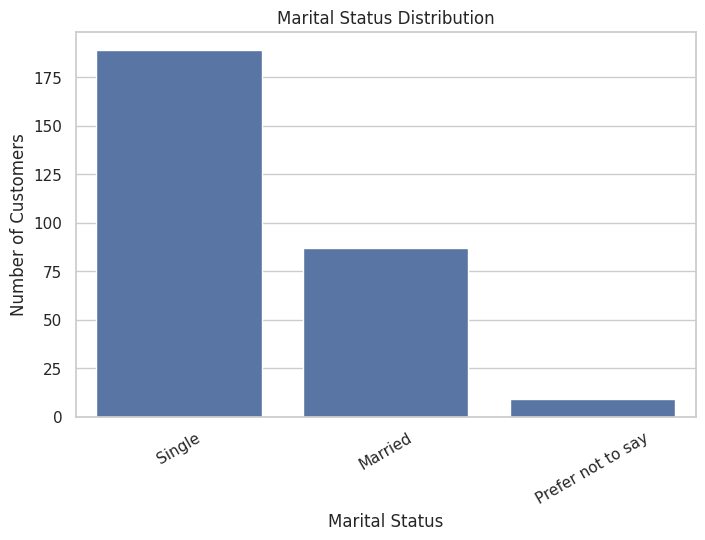

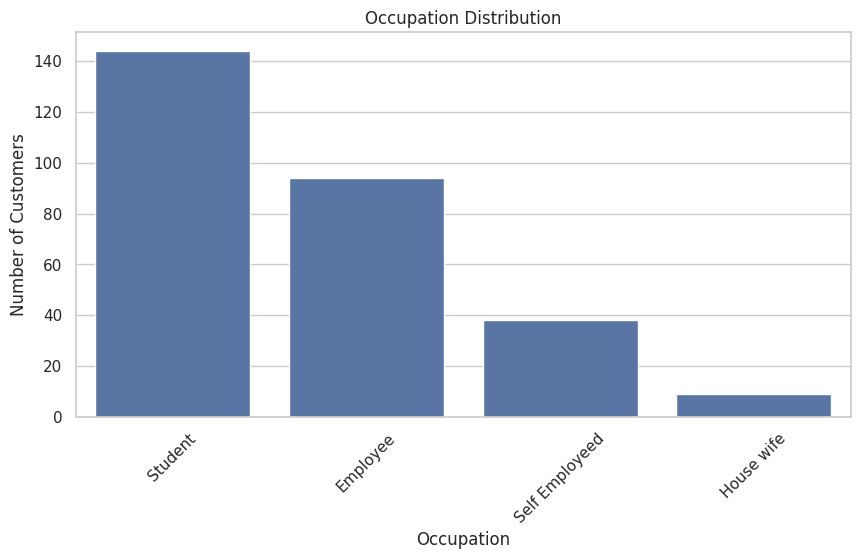

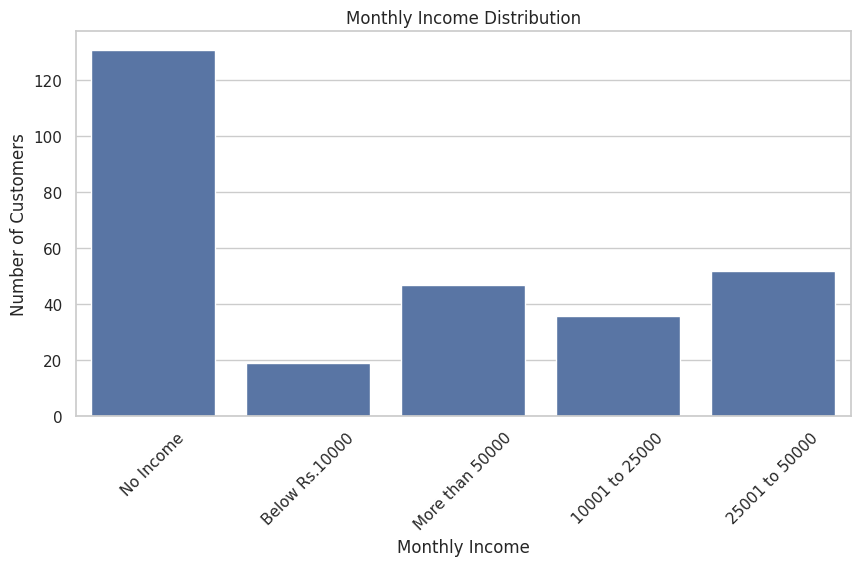

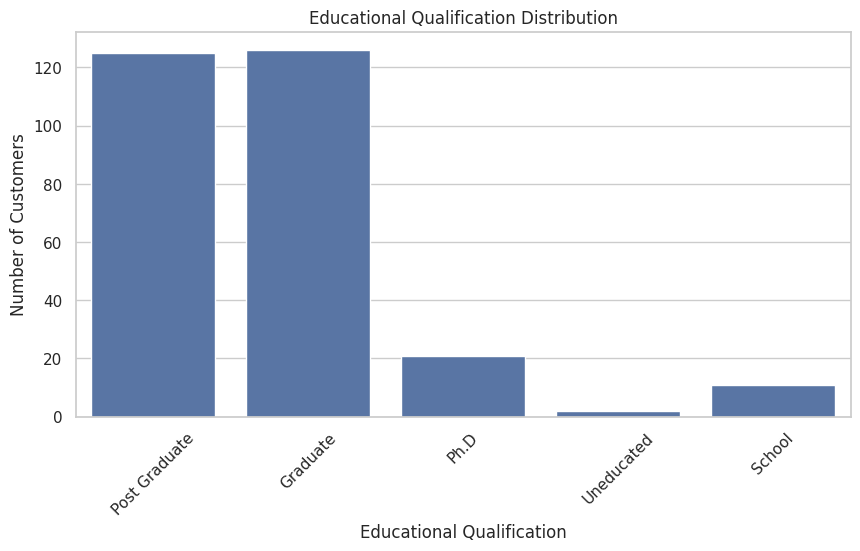

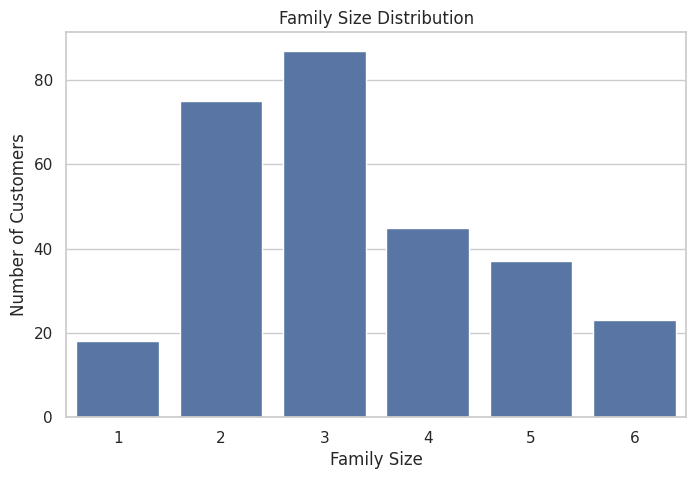

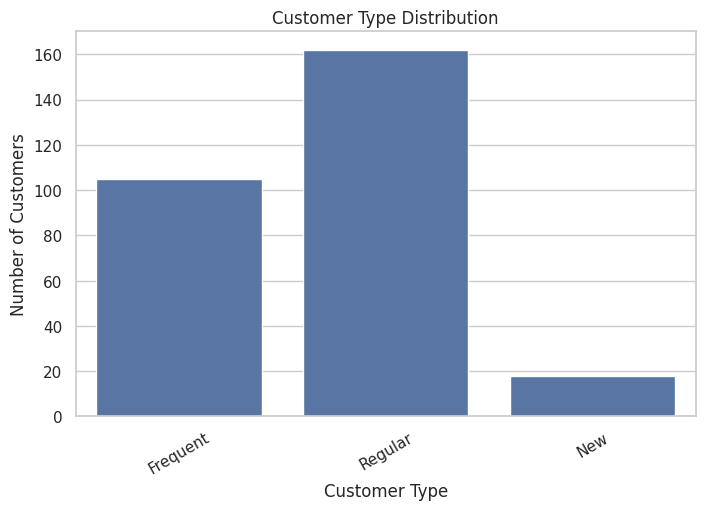

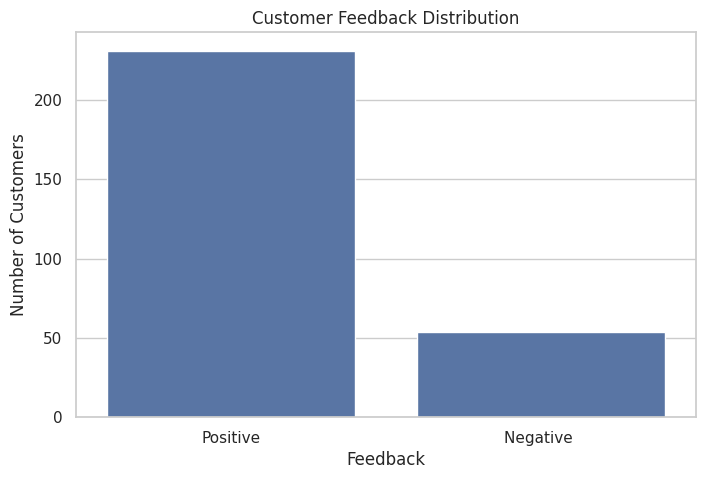

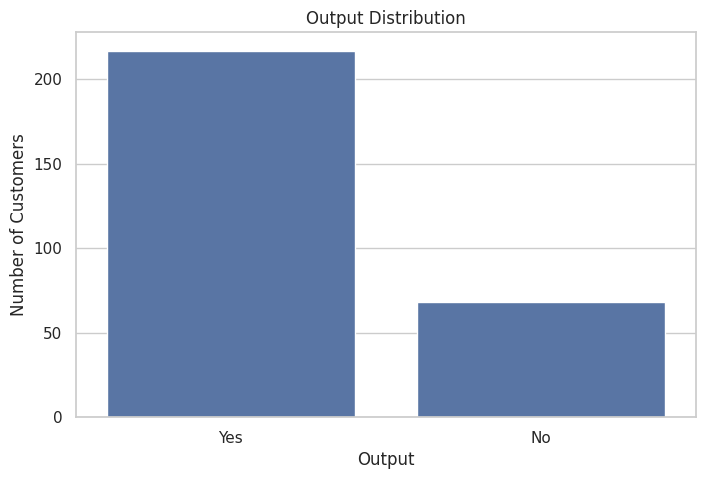

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Basic setup
# -----------------------------
sns.set_theme(style="whitegrid")

# Remove unnecessary column
df = df.drop(columns=["Unnamed: 13"], errors="ignore")

# -----------------------------
# 1. Age Distribution
# -----------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# -----------------------------
# 2. Gender Distribution
# -----------------------------
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# -----------------------------
# 3. Marital Status
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Marital Status")
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

# -----------------------------
# 4. Occupation
# -----------------------------
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Occupation")
plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 5. Monthly Income
# -----------------------------
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Monthly Income")
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 6. Educational Qualifications
# -----------------------------
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Educational Qualifications")
plt.title("Educational Qualification Distribution")
plt.xlabel("Educational Qualification")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 7. Family Size
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Family size")
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Customers")
plt.show()

# -----------------------------
# 8. Customer Type
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Customer Type")
plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

# -----------------------------
# 9. Feedback
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Feedback")
plt.title("Customer Feedback Distribution")
plt.xlabel("Feedback")
plt.ylabel("Number of Customers")
plt.show()

# -----------------------------
# 10. Output
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Output")
plt.title("Output Distribution")
plt.xlabel("Output")
plt.ylabel("Number of Customers")
plt.show()

## Features Engineering

Original Shape: (285, 13)

Number of duplicate rows:
0
Shape after removing duplicates: (285, 13)

Missing values before handling:
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
dtype: int64

Missing values after handling:
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                

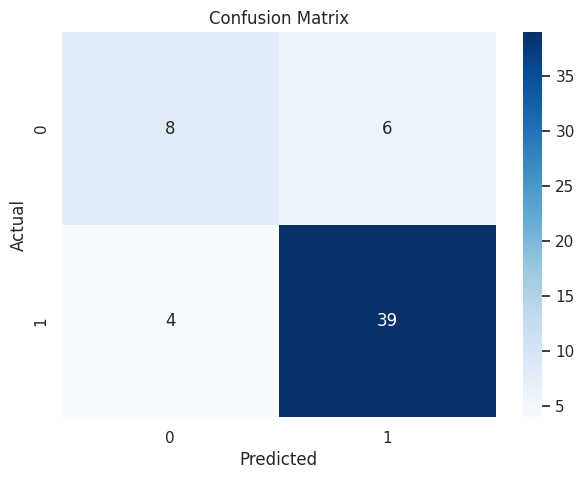


       TOP 20 IMPORTANT FEATURES
                                              Feature  Importance
29                    categorical__Feedback_Negative     0.094961
30                     categorical__Feedback_Positive    0.092876
2                                   numeric__latitude    0.066315
5                                numeric__Age_Squared    0.060183
3                                  numeric__longitude    0.058473
4                                   numeric__Pin code    0.055681
0                                        numeric__Age    0.055383
11                 categorical__Marital Status_Single    0.029598
1                                numeric__Family size    0.027136
15                    categorical__Occupation_Student    0.023690
35           categorical__Family_Size_Category_Medium    0.018592
20              categorical__Monthly Income_No Income    0.017319
62                  categorical__Location_12.96_77.56    0.017164
70                  categorical__Location_

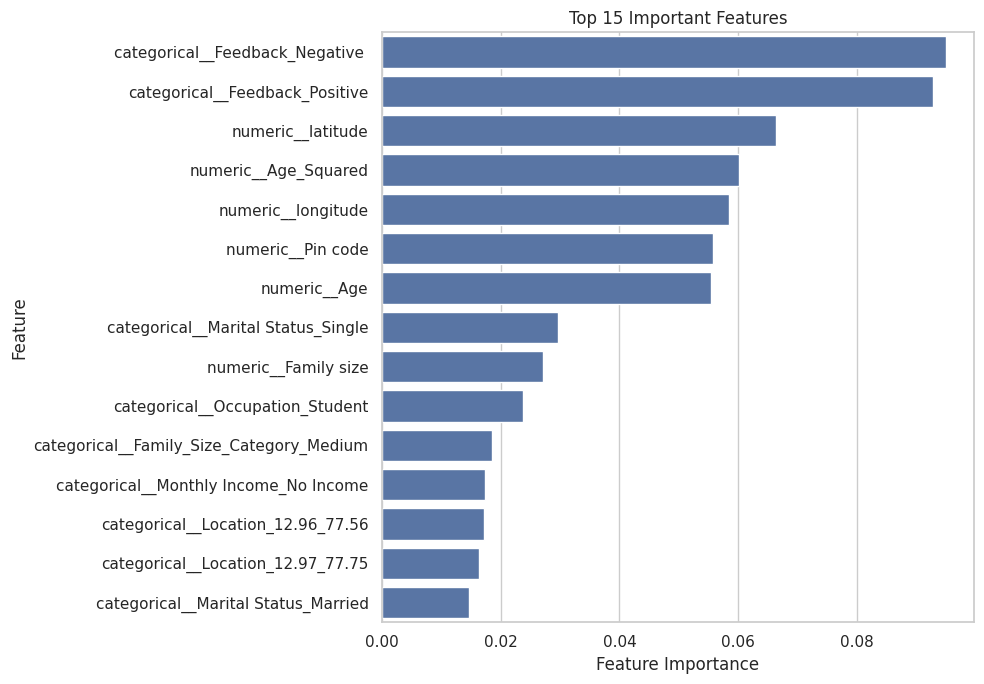


Actual vs Predicted:
   Actual Predicted
0     Yes       Yes
1      No       Yes
2      No       Yes
3     Yes       Yes
4      No        No
5      No       Yes
6     Yes       Yes
7      No        No
8      No        No
9     Yes        No
10    Yes       Yes
11    Yes       Yes
12    Yes       Yes
13    Yes       Yes
14    Yes       Yes
15    Yes       Yes
16    Yes       Yes
17    Yes       Yes
18    Yes       Yes
19    Yes       Yes


In [19]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# 1. LOAD DATA
# =========================================================

# If already loaded, keep this commented
# df = pd.read_csv("your_file.csv")

print("Original Shape:", df.shape)

# =========================================================
# 2. REMOVE UNNECESSARY COLUMN
# =========================================================

df = df.drop(columns=["Unnamed: 13"], errors="ignore")

# =========================================================
# 3. CHECK DUPLICATES
# =========================================================

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

# =========================================================
# 4. CHECK MISSING VALUES
# =========================================================

print("\nMissing values before handling:")
print(df.isnull().sum())

# =========================================================
# 5. CLEAN NUMERIC COLUMNS
# =========================================================

numeric_columns = [
    "Age",
    "Family size",
    "latitude",
    "longitude",
    "Pin code"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================================
# 6. HANDLE MISSING VALUES
# =========================================================

# Numeric columns -> Median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_columns = [
    "Gender",
    "Marital Status",
    "Occupation",
    "Monthly Income",
    "Educational Qualifications",
    "Customer Type",
    "Feedback"
]

for col in categorical_columns:
    if df[col].isnull().any():
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing values after handling:")
print(df.isnull().sum())

# =========================================================
# 7. FEATURE ENGINEERING
# =========================================================

# ---------------------------------------------------------
# Age Group
# ---------------------------------------------------------

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, np.inf],
    labels=[
        "Teen",
        "Young Adult",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

# ---------------------------------------------------------
# Family Size Category
# ---------------------------------------------------------

df["Family_Size_Category"] = pd.cut(
    df["Family size"],
    bins=[0, 2, 4, 6, np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

# ---------------------------------------------------------
# Income Level
# ---------------------------------------------------------
# We DO NOT use qcut because Monthly Income
# may contain repeated values or income ranges.

df["Income_Level"] = df["Monthly Income"].astype(str)

# ---------------------------------------------------------
# Age Squared
# ---------------------------------------------------------

df["Age_Squared"] = df["Age"] ** 2

# ---------------------------------------------------------
# Large Family Indicator
# ---------------------------------------------------------

df["Large_Family"] = (
    df["Family size"] >= 5
).astype(int)

# ---------------------------------------------------------
# Location Feature
# ---------------------------------------------------------

df["Location"] = (
    df["latitude"].round(2).astype(str)
    + "_"
    + df["longitude"].round(2).astype(str)
)

print("\nFeature engineering completed!")

print("\nNew columns:")
print(df.columns.tolist())

# =========================================================
# 8. TARGET VARIABLE
# =========================================================

target = "Output"

# Remove rows where target is missing
df = df.dropna(subset=[target])

# X = Features
# y = Target

X = df.drop(columns=[target])
y = df[target]

print("\nTarget distribution:")
print(y.value_counts())

# =========================================================
# 9. IDENTIFY NUMERIC & CATEGORICAL FEATURES
# =========================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# =========================================================
# 10. PREPROCESSING
# =========================================================

# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

# Combine both
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

# =========================================================
# 11. TRAIN / TEST SPLIT
# =========================================================

# Check whether stratification is possible
if y.value_counts().min() >= 2:
    stratify_value = y
else:
    stratify_value = None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_value
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

# =========================================================
# 12. RANDOM FOREST CLASSIFIER
# =========================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

# =========================================================
# 13. TRAIN MODEL
# =========================================================

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

# =========================================================
# 14. PREDICTION
# =========================================================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# =========================================================
# 15. ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("\n====================================")
print("           MODEL ACCURACY")
print("====================================")

print(
    "Training Accuracy :",
    round(train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy  :",
    round(test_accuracy * 100, 2),
    "%"
)

# =========================================================
# 16. CLASSIFICATION REPORT
# =========================================================

print("\n====================================")
print("       CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

# =========================================================
# 17. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n====================================")
print("         CONFUSION MATRIX")
print("====================================")

print(cm)

# Visualization
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

# Get processed feature names
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get importance
importance = model.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n====================================")
print("       TOP 20 IMPORTANT FEATURES")
print("====================================")

print(
    feature_importance.head(20)
)

# =========================================================
# 19. FEATURE IMPORTANCE VISUALIZATION
# =========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# =========================================================
# 20. ACTUAL VS PREDICTED
# =========================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

print("\nActual vs Predicted:")
print(comparison.head(20))

## Thanks.............Please Upvote